In [1]:
import matplotlib.pyplot as plt

from config import PLOTS_DIR
from core.joint_sr_var import NormalDGP, StudentTDGP, GaussianMixtureDGP
from core.joint_sr_var import analyze, plot_results


Gaussian
  moments  : mu=+0.0500  sigma=0.1500  skew=+0.000  kurt=3.000
  truth    : SR=+0.3333  VaR=0.2990
  par.tgt  : VaR=0.2990  (asymp bias -0.0000)
  Empirical : MSE=6.05e-04  bias=-0.0057  cov=95.36%
  Parametric: MSE=1.66e-04  bias=-0.0001  cov=94.99%


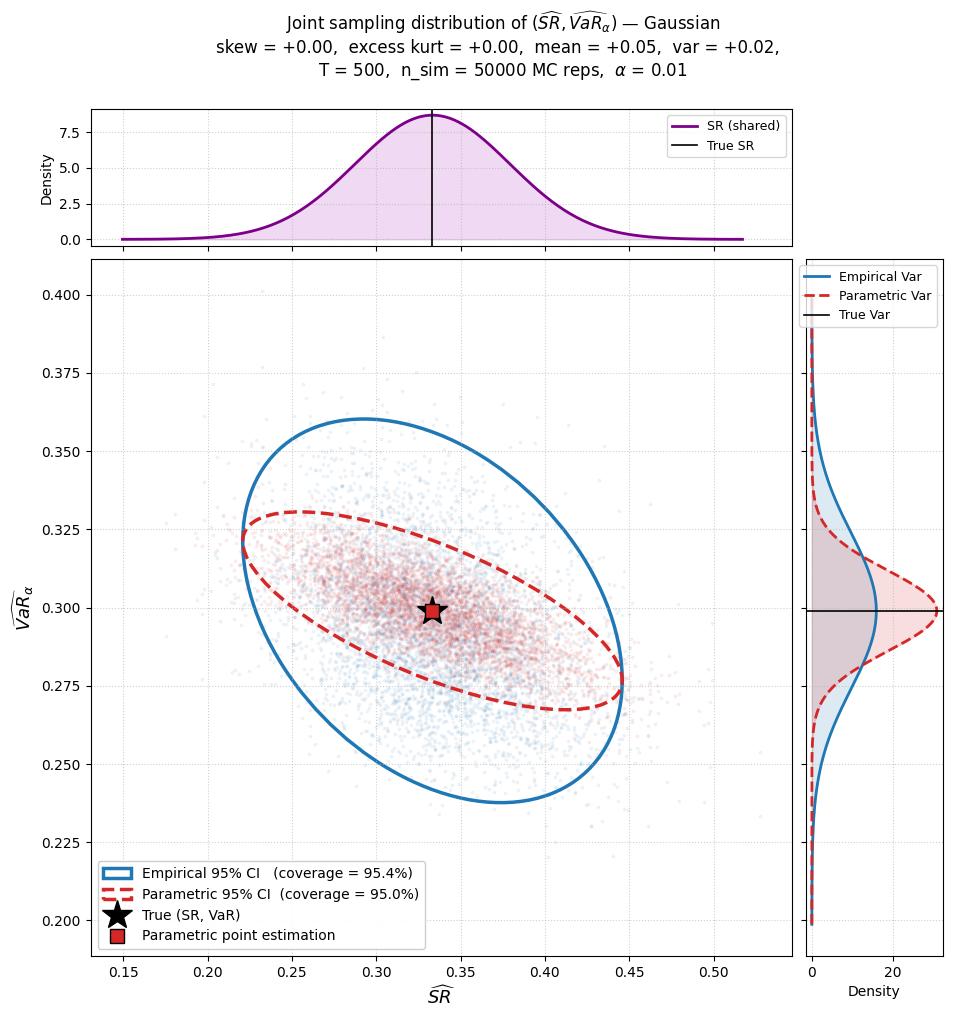


Student-t(6)
  moments  : mu=+0.0500  sigma=0.1837  skew=+0.000  kurt=6.000
  truth    : SR=+0.2722  VaR=0.4214
  par.tgt  : VaR=0.3774  (asymp bias -0.0440)
  Empirical : MSE=2.63e-03  bias=-0.0100  cov=95.44%
  Parametric: MSE=2.49e-03  bias=-0.0445  cov=14.84%


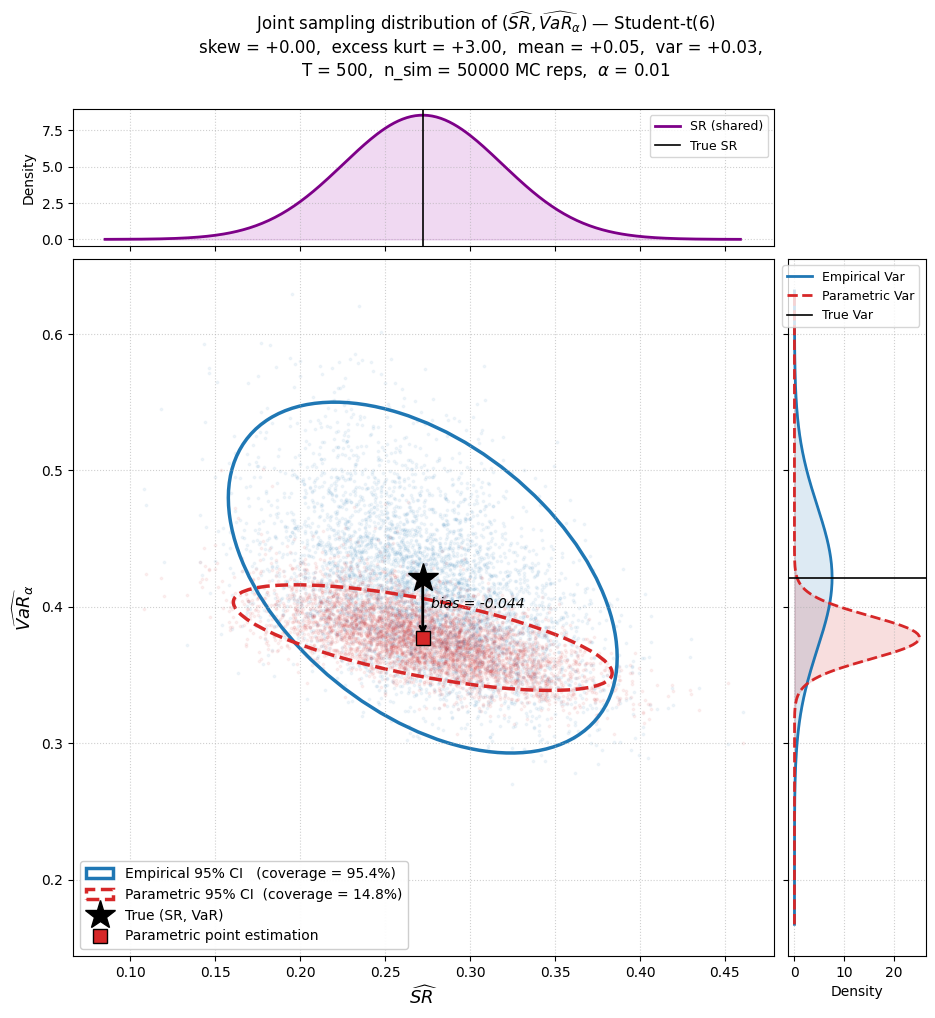

In [2]:
cfg = dict(alpha=0.01, T=500, n_sim=50000, tau=0.95, seed=7)
dgps = {
    'Gaussian': NormalDGP(mu=0.05, sigma=0.15),
    # 'Heavy-skew mixture': GaussianMixtureDGP(
    #     weights=[0.99, 0.01],
    #     means  =[0.082, -0.131],
    #     sigmas =[0.082,  0.245]),
    'Student-t(6)': StudentTDGP(mu=0.05, sigma=0.15, nu=6)
}

for label, dgp in dgps.items():
    print(f'\n{"="*64}\n{label}\n{"="*64}')
    res = analyze(dgp, **cfg)
    d, m = res['diagnostics'], res['moments']
    print(f"  moments  : mu={m['mu']:+.4f}  sigma={m['sigma']:.4f}  "
            f"skew={m['skew']:+.3f}  kurt={m['kurt']:.3f}")
    print(f"  truth    : SR={res['truth']['SR']:+.4f}  "
            f"VaR={res['truth']['VaR']:.4f}")
    print(f"  par.tgt  : VaR={res['asym_target']['VaR_par']:.4f}  "
            f"(asymp bias {res['asym_target']['asymp_bias_par']:+.4f})")
    print(f"  Empirical : MSE={d['mc_mse_emp']:.2e}  "
            f"bias={d['mc_bias_emp']:+.4f}  cov={d['coverage_emp']:.2%}")
    print(f"  Parametric: MSE={d['mc_mse_par']:.2e}  "
            f"bias={d['mc_bias_par']:+.4f}  cov={d['coverage_par']:.2%}")

    out = (PLOTS_DIR / f'sr_var_{label.lower().replace(" ", "_").replace("-", "_")}.png')
    plot_results(res, dgp_label=label, save_path=out)
    plt.show()